In [1]:
import pandas as pd

fake = pd.read_csv("../data/raw/Fake.csv")
real = pd.read_csv("../data/raw/Real.csv")

In [2]:
print("Fake news shape:", fake.shape)
print("Real news shape:", real.shape)

Fake news shape: (23481, 4)
Real news shape: (21417, 4)


In [3]:
print("Fake news columns:")
print(fake.columns)

print("\nReal news columns:")
print(real.columns)

Fake news columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')

Real news columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [7]:
fake.head()


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [8]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [26]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [27]:
real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [30]:
# missing values
print(fake.isnull().sum())


title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [29]:
print(real.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:
# duplicate rows
print("Fake duplicates:", fake.duplicated().sum())

Fake duplicates: 3


In [35]:
print("Real duplicates:", real.duplicated().sum())

Real duplicates: 206


In [ ]:
# exploring the text
print(fake["title"].iloc[0])
print(fake["text"].iloc[0])

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this d

In [34]:
print(real["title"].iloc[0])
print(real["text"].iloc[0])

As U.S. budget fight looms, Republicans flip their fiscal script
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-

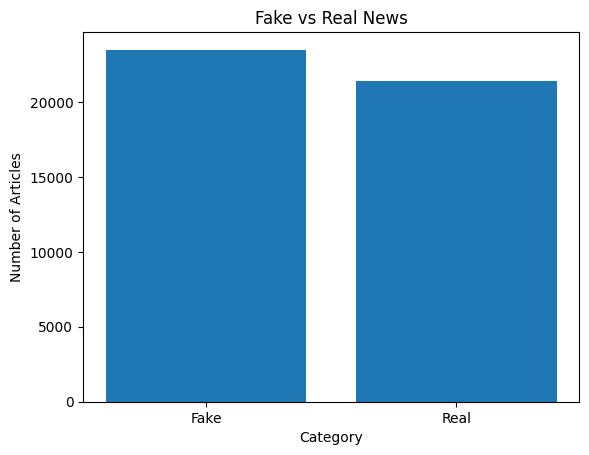

In [36]:
import matplotlib.pyplot as plt

counts = [len(fake), len(real)]
labels = ["Fake", "Real"]

plt.bar(labels, counts)
plt.title("Fake vs Real News")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()

In [37]:
# analyze article lengths
fake["text_length"] = fake["text"].str.len()
real["text_length"] = real["text"].str.len()

In [38]:
print(fake["text_length"].describe())
print(real["text_length"].describe())

count    23481.000000
mean      2547.396235
std       2532.884399
min          1.000000
25%       1433.000000
50%       2166.000000
75%       3032.000000
max      51794.000000
Name: text_length, dtype: float64
count    21417.000000
mean      2383.278517
std       1684.835730
min          1.000000
25%        914.000000
50%       2222.000000
75%       3237.000000
max      29781.000000
Name: text_length, dtype: float64


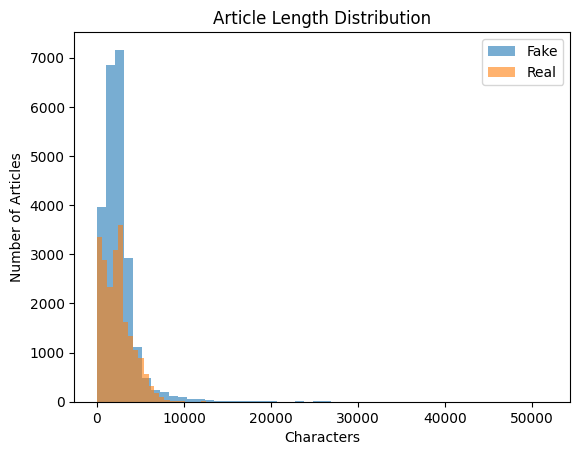

In [39]:
plt.hist(fake["text_length"], bins=50, alpha=0.6, label="Fake")
plt.hist(real["text_length"], bins=50, alpha=0.6, label="Real")

plt.title("Article Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Articles")
plt.legend()

plt.show()